## Devoir : apprentissage par renforcement dans Grid World

### Instructions :
1. Initialiser le Grid World avec une largeur, une hauteur et des positions bloquées données.
2. Implémenter un agent Q-Learning et un agent SARSA pour naviguer dans le Grid World.
3. Entraîner l'agent à atteindre la position objectif depuis la position de départ tout en évitant les positions bloquées.
4. Visualiser la progression de l'agent en affichant la grille à chaque étape.
5. Adapter le code à Grid World v2, qui contient des murs, des marais et des falaises.
    - Un mur bloque le déplacement de l'agent.
    - Un marais donne une récompense négative à l'agent.
    - Une falaise transporte l'agent au point de départ.
6. Expérimenter avec différentes valeurs de alpha, gamma, différentes récompenses et d'autres paramètres afin d'observer leurs effets sur les agents dans 5 cartes différentes.
7. Analyser les performances des agents en mesurant le nombre d'étapes nécessaires pour atteindre l'objectif à chaque épisode, comparer l'agent Q-Learning et l'agent SARSA, puis expliquer le résultat.


Voici un exemple utilisant l'interface pygame pour simuler un agent aléatoire.

In [1]:
from grid_world import GridWorld, PygameGridWorld
import numpy as np
# vérifiez la barre des tâches pour voir l'application pygame GridWorld en cours d'exécution
game = PygameGridWorld()
grid_world = game.grid_world

# exemple d'utilisation de GridWorld : nous montrons les fonctions de base pour
# state, action, next_state et reached_goal
state = grid_world.player_position
action = np.random.choice(grid_world.actions)
reached_goal = grid_world.move_player(action)
next_state = grid_world.player_position
print("état, action, état_suivant, objectif_atteint")
print(state, action, next_state, reached_goal)

game.main(auto_close=True) # auto_close ferme automatiquement l'écran à la fin du jeu.


pygame 2.6.1 (SDL 2.28.4, Python 3.11.0)
Hello from the pygame community. https://www.pygame.org/contribute.html
état, action, état_suivant, objectif_atteint
(0, 0) down (0, 1) False


### Agent Q-Learning
L'agent Q-Learning est un algorithme qui apprend à prendre des décisions à partir des récompenses qu'il reçoit. C'est un algorithme d'apprentissage par renforcement sans modèle qui apprend à estimer la valeur d'une action dans un état donné. C'est un algorithme hors politique (*off-policy*), ce qui signifie qu'il apprend une politique différente de la politique d'exploration. L'algorithme est composé de plusieurs éléments :
- L'agent Q-Learning utilise une table Q pour stocker les valeurs de chaque action dans chaque état.
- L'agent met à jour la table Q après chaque action en fonction de la récompense reçue et de la valeur Q maximale de l'état suivant.
- L'agent choisit l'action ayant la valeur Q la plus élevée dans chaque état.

La valeur Q d'une paire état-action est mise à jour avec l'expression récurrente suivante :

$$Q(s_t,a_t) \leftarrow  Q(s_t,a_t) + \alpha (R_{t+1} + \gamma \max_{a} Q(s_{t+1},a)-Q(s_t,a_t))$$

où $s$ est l'état courant, $a$ l'action effectuée dans cet état, $r$ la récompense reçue pour cette action, $s_{t+1}$ l'état suivant, $\alpha$ le taux d'apprentissage et $\gamma$ le facteur d'actualisation. Le taux d'apprentissage détermine le poids accordé aux nouvelles informations, tandis que le facteur d'actualisation détermine l'importance des récompenses futures. L'agent met à jour sa table Q après chaque action et choisit l'action ayant la valeur Q la plus élevée dans chaque état.

**Implémentations à réaliser pour la méthode d'apprentissage Q-Learning** :
- compléter les affectations dans la fonction **choose_action()**
- compléter les affectations dans la fonction **learn()**


In [2]:
import random
import numpy as np

class QLearningAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = list(grid_world.actions) if hasattr(grid_world, "actions") else ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)

        q_values = [self.get_q_value(state, action) for action in self.actions]
        max_q_value = max(q_values)
        best_actions = [action for action, value in zip(self.actions, q_values) if value == max_q_value]
        return random.choice(best_actions)

    def learn(self, state, action, reward, next_state):
        current_q_value = self.get_q_value(state, action)
        next_q_values = [self.get_q_value(next_state, next_action) for next_action in self.actions]
        max_next_q_value = max(next_q_values)
        new_q_value = current_q_value + self.alpha * (
            reward + self.gamma * max_next_q_value - current_q_value
        )
        self.update_q_value(state, action, new_q_value)


### Agent SARSA

L'agent SARSA est un algorithme d'apprentissage par renforcement utilisé pour apprendre la politique optimale dans un environnement donné. C'est un algorithme sur politique (*on-policy*), ce qui signifie qu'il apprend la fonction de valeur pour la politique qu'il suit actuellement. L'algorithme fonctionne en mettant à jour la valeur Q de la paire état-action courante à partir de la récompense reçue et de la valeur Q de la paire état-action suivante. La règle de mise à jour est la suivante :

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha(R_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t))$$

où $s_t$ est l'état courant, $a_t$ l'action courante, $R_{t+1}$ la récompense reçue après avoir effectué l'action $a_t$ dans l'état $s_t$, $s_{t+1}$ l'état suivant, $a_{t+1}$ l'action suivante, $\alpha$ le taux d'apprentissage et $\gamma$ le facteur d'actualisation.

**Implémentations à réaliser pour la méthode d'apprentissage SARSA** :
- compléter les affectations dans la fonction **choose_action()**
- compléter les affectations dans la fonction **learn()**


In [3]:
# Créer une classe d'agent SARSA
class SarsaAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = list(grid_world.actions) if hasattr(grid_world, "actions") else ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)

        q_values = [self.get_q_value(state, action) for action in self.actions]
        max_q_value = max(q_values)
        best_actions = [action for action, value in zip(self.actions, q_values) if value == max_q_value]
        return random.choice(best_actions)

    def learn(self, state, action, reward, next_state, next_action):
        current_q_value = self.get_q_value(state, action)
        next_q_value = self.get_q_value(next_state, next_action)
        new_q_value = current_q_value + self.alpha * (
            reward + self.gamma * next_q_value - current_q_value
        )
        self.update_q_value(state, action, new_q_value)


### Expériences
L'expérience porte sur la comparaison de deux types d'agents : Q-Learning et SARSA. Nous comparons le nombre total d'étapes et les récompenses cumulées par époque pendant l'exécution afin d'observer leurs comportements différents.

**Remarque** : l'agent SARSA est un algorithme sur politique (*on-policy*), donc l'action suivante est réutilisée à l'itération suivante. L'agent Q-Learning est un algorithme hors politique (*off-policy*), donc l'action suivante sera tirée à nouveau à l'itération suivante.

**Implémentations à réaliser** :
- def train_q_learning_agent()
- def train_sarsa_agent()

**Tâches à faire** :
- tracer le nombre total d'étapes et les récompenses
- tracer la table des valeurs Q et la table des actions
- comparer l'agent Q-Learning et l'agent SARSA
- rédiger une conclusion


In [4]:
import matplotlib.pyplot as plt
import pickle


def get_intended_position(state, action, grid_world):
    x, y = state
    if action == "up":
        y = max(0, y - 1)
    elif action == "down":
        y = min(grid_world.height - 1, y + 1)
    elif action == "left":
        x = max(0, x - 1)
    elif action == "right":
        x = min(grid_world.width - 1, x + 1)
    return (x, y)


def get_reward(grid_world, reached_goal, intended_position, reward_goal=100, reward_default=-1,
               reward_marsh=-10, reward_cliff=-100):
    if reached_goal:
        return reward_goal
    if intended_position in getattr(grid_world, "cliff_positions", []):
        return reward_cliff
    if intended_position in getattr(grid_world, "marsh_positions", []):
        return reward_marsh
    return reward_default


def train_q_learning_agent(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    rewards = 0
    while not grid_world.is_game_over() and steps < max_steps:
        state = grid_world.player_position
        action = agent.choose_action(state)
        intended_position = get_intended_position(state, action, grid_world)
        reached_goal = grid_world.move_player(action)
        next_state = grid_world.player_position
        reward = get_reward(grid_world, reached_goal, intended_position, **rewards_config)
        agent.learn(state, action, reward, next_state)
        steps += 1
        rewards += reward
    return steps, rewards


def train_sarsa_agent(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    rewards = 0
    state = grid_world.player_position
    action = agent.choose_action(state)
    while not grid_world.is_game_over() and steps < max_steps:
        intended_position = get_intended_position(state, action, grid_world)
        reached_goal = grid_world.move_player(action)
        next_state = grid_world.player_position
        reward = get_reward(grid_world, reached_goal, intended_position, **rewards_config)
        next_action = agent.choose_action(next_state)
        agent.learn(state, action, reward, next_state, next_action)

        state = next_state
        action = next_action
        steps += 1
        rewards += reward
    return steps, rewards


In [5]:
def ExperimentAgent(your_agent_class_object,
                    epsilon=0.9, epsilon_decay=0.15,
                    num_episodes=50, alpha=0.1, gamma=0.99,
                    grid_world=None, max_steps=200, rewards_config=None):
    if grid_world is None:
        grid_world = GridWorld(10, 10,
                        wall_positions=[ (1, 1), (2, 2), (3, 3), (4, 4),
                                            (3, 2), (3, 1),
                                            (5, 5), (5,0),
                                            (6, 1), (6,2), (6,3),
                                            (8, 9), (8, 8),  (8, 7),(8, 6),
                                            (8, 5), (8, 4),(8, 3),(8, 2),],
                        goal_positions=[(9,9)])
    YourAgentClass = your_agent_class_object
    agent = YourAgentClass(grid_world, alpha=alpha,
                           gamma=gamma, epsilon=epsilon)

    steps_per_episode = []
    reward_per_episode = []
    for episode in range(num_episodes):
        grid_world.player_position = grid_world.init_player_position
        if agent.__class__.__name__ == "QLearningAgent":
            steps, rewards = train_q_learning_agent(agent, grid_world, max_steps, rewards_config)
        elif agent.__class__.__name__ == "SarsaAgent":
            steps, rewards = train_sarsa_agent(agent, grid_world, max_steps, rewards_config)
        else:
            raise ValueError(f"Agent non supporté : {agent.__class__.__name__}")

        steps_per_episode.append(steps)
        reward_per_episode.append(rewards)

        # enregistrer les politiques apprises dans des fichiers pickle
        if episode % 50 == 0:
            agent.epsilon = max(0.1, agent.epsilon - epsilon_decay)
            # Enregistrer la politique apprise
            with open(f"learned_policy_{YourAgentClass.__name__}_episode_{episode}.pkl", "wb") as f:
                pickle.dump(agent.q_table, f)

    # Sauvegarde aussi la politique finale pour faciliter l'analyse.
    with open(f"learned_policy_{YourAgentClass.__name__}_episode_{num_episodes}.pkl", "wb") as f:
        pickle.dump(agent.q_table, f)

    print(f"{YourAgentClass.__name__} entraîné pendant {num_episodes} épisodes")

    return steps_per_episode, reward_per_episode, agent


In [6]:
steps_per_episode_QLearning, reward_per_episode_QLearning, q_learning_agent = ExperimentAgent(QLearningAgent)
steps_per_episode_Sarsa, reward_per_episode_Sarsa, sarsa_agent = ExperimentAgent(SarsaAgent)


QLearningAgent entraîné pendant 50 épisodes
SarsaAgent entraîné pendant 50 épisodes


In [7]:
def plot_comparison(steps_per_episode_QLearning, reward_per_episode_QLearning,
                    steps_per_episode_Sarsa, reward_per_episode_Sarsa):

    # Tracer le graphe des Étapes par Épisode
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(steps_per_episode_QLearning, color='blue', alpha=0.7)
    ax1.plot(steps_per_episode_Sarsa, color='orange', alpha=0.7)
    ax1.set_xlabel('Épisode')
    ax1.set_ylabel('Étapes')
    ax1.legend(['QLearningAgent' ,'SarsaAgent'])
    ax1.set_title("Nombre total d'Étapes par Épisode")
    ax1.set_yscale('log')

    # Tracer le graphe des récompenses par Épisode
    ax2.plot(reward_per_episode_QLearning, color='blue', alpha=0.7)
    ax2.plot(reward_per_episode_Sarsa, color='orange', alpha=0.7)
    ax2.set_xlabel('Épisode')
    ax2.set_ylabel('Récompenses cumulées')
    ax2.legend(['QLearningAgent' ,'SarsaAgent'])
    ax2.set_title('Récompenses cumulées par Épisode')
    plt.tight_layout()
    plt.show()


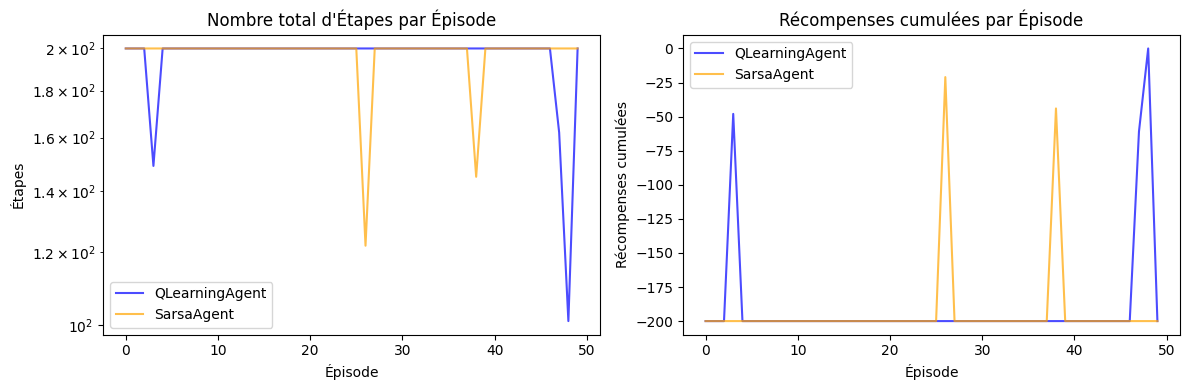

In [8]:
plot_comparison(
    steps_per_episode_QLearning, reward_per_episode_QLearning,
    steps_per_episode_Sarsa, reward_per_episode_Sarsa
)


In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def plot_q_values_and_action_table(q_table, agent_name, grid_size=(10, 10)):
    action_arrow = {"left": '\u2190', "right": '\u2192', "up": '\u2191', "down": '\u2193'}

    # Hypothèse : une grille 10x10 comme dans le code initial
    mat = np.zeros(grid_size) - np.inf
    directions = np.full(grid_size, '', dtype=object)

    # Traiter la table Q pour la visualisation
    for ((x, y), action), value in q_table.items():
        if 0 <= y < grid_size[0] and 0 <= x < grid_size[1] and mat[y, x] < value:
            mat[y, x] = value
            directions[y, x] = action_arrow[action]

    # Tracé
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))
    mat[~np.isfinite(mat)] = 0
    vmin, vmax = np.min(mat), np.max(mat)

    # carte thermique des valeurs Q
    sns.heatmap(mat, annot=mat, fmt=".0f", cmap="vlag", ax=ax[0], annot_kws={"fontsize":12})
    ax[0].set_title(f"{agent_name} - table des valeurs Q")
    ax[0].collections[0].set_clim(vmin, vmax)

    # carte thermique des actions
    sns.heatmap(mat, annot=directions, fmt='', cmap="vlag", ax=ax[1], annot_kws={"fontsize":28})
    ax[1].set_title(f"{agent_name} - table des actions")
    ax[1].collections[0].set_clim(vmin, vmax)

    plt.show()


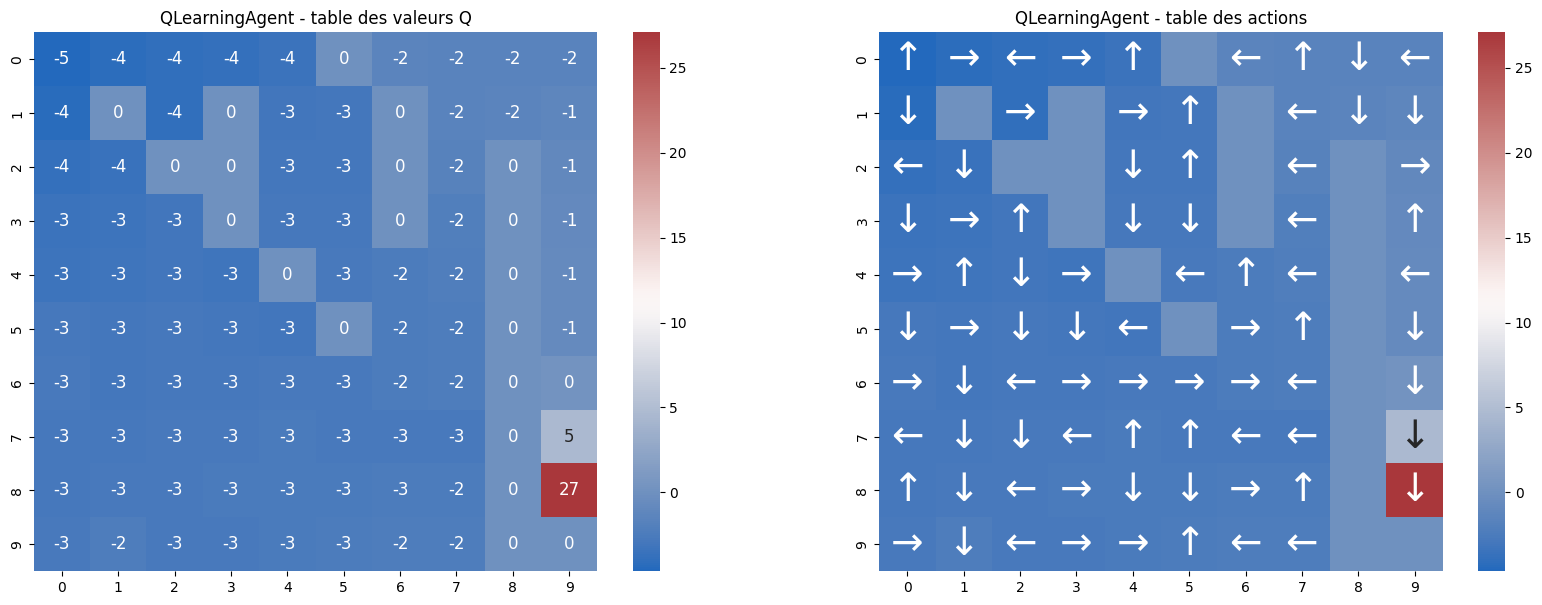

KeyboardInterrupt: 

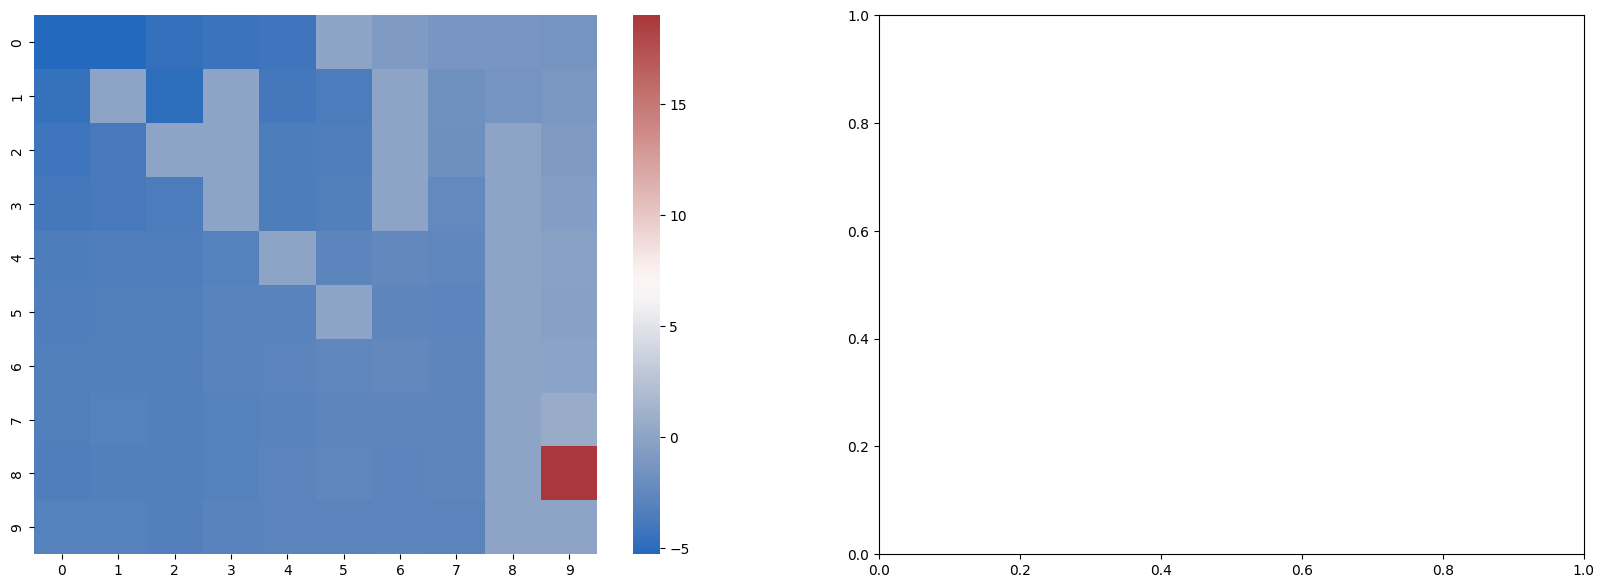

In [10]:
plot_q_values_and_action_table(q_learning_agent.q_table, 'QLearningAgent')
plot_q_values_and_action_table(sarsa_agent.q_table, 'SarsaAgent')


In [ ]:
from grid_world import SimulationGridWorld
SimulationGridWorld(SarsaAgent, # QLearningAgent, SarsaAgent
                    params={"gamma":0.99,
                            "epsilon":0.1, 
                            "alpha":0.1},
                    episode=50, 
                    grid_world=None,
                    auto_replay=False, 
                    ticks=10) # ticks correspond aux images par seconde

### Conclusion

--- votre conclusion pour la première partie ---

### Applications sur différentes cartes de Grid World (optionnel)
Dans cette deuxième partie du devoir Grid World, les blocs utilisés dans les configurations sont indiqués ci-dessous :
- Le bloc gris marque le point de départ du jeu.
- Les blocs verts (4) indiquent la destination à atteindre.
- Le bloc rouge représente le joueur.
- Les blocs blancs (0) représentent les routes praticables.
- Les blocs bleus (1) symbolisent les murs qui bloquent l'agent.
- Les blocs jaunes (2) indiquent les falaises qui ramènent l'agent au point de départ.
- Les blocs marron (3) représentent les marais qui donnent une récompense négative à l'agent.

**Tâches à faire** :
- Modifier alpha, gamma, epsilon, les récompenses, etc. afin de s'assurer que le nombre d'étapes par épisode des agents converge à la fin des expériences.
- Chercher, pour toutes les configurations, des paramètres avec lesquels l'agent Q-Learning et l'agent SARSA choisissent des chemins différents dans le Grid World.
- Discuter la solution finale, c'est-à-dire le chemin optimal obtenu dans les expériences.
- Discuter le nombre total d'étapes et les récompenses cumulées pour Q-Learning et SARSA.
- Discuter la table Q et la table d'actions pour Q-Learning et SARSA.

- Discuter les différents comportements des agents Q-Learning et SARSA à partir de vos expériences sur toutes les configurations.

**Remarque**
- Des fonctions d'exemple sont fournies pour lire une carte et ses paramètres depuis <<datas.json>>.
- La modification des récompenses, de gamma, de alpha, etc. doit être effectuée dans <<datas.json>>.


Voici un exemple de chargement des données depuis le jeu de données JSON.

In [ ]:
from grid_world import load_data
datas = load_data()
map_name = 'map_16'
key_list = datas[map_name].keys()
print("key_list:", key_list)

map = datas[map_name]["map"]
print('\nmap_name:', map_name)
for line in map:
    print(line)

print("params_list:", datas[map_name]["parameters"])

loaded maps : dict_keys(['map_1', 'map_2', 'map_7', 'map_8', 'map_12', 'map_16'])
key_list: dict_keys(['map', 'start_place_x', 'start_place_y', 'parameters'])

map_name: map_16
[0, 0, 2, 2, 2, 2, 2, 2, 0, 4]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
params_list: {'alpha': 0.05, 'gamma': 0.99, 'epsilon': 0.9, 'episodes': 1000, 'epsilon_min': 0.01, 'epsilon_decay_rate': 0.01, 'reward_final': 1000, 'reward_marsh': -10, 'step_limit': 1000, 'reward_default': -1}


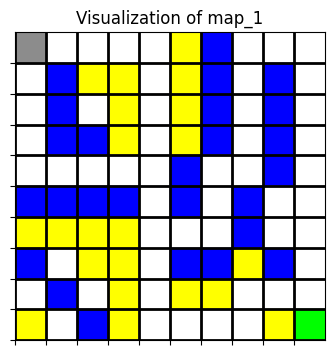

In [ ]:
from grid_world import *
plot_grid_world(datas, "map_1")

In [ ]:
from grid_world import GridWorld, PygameGridWorld

# vérifiez la barre des tâches pour voir l'application pygame GridWorld en cours d'exécution
game = PygameGridWorld()
game.main(auto_close=True, map_name="map_1", datas=datas) # auto_close ferme automatiquement l'écran à la fin du jeu.


### Expériences